## 1. Постановка задачи

<center> <img src=https://storage.googleapis.com/kaggle-competitions/kaggle/3333/media/taxi_meter.png align="right" width="300"/> </center>
    
Вам предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Мы построим модель, которая будет предсказывать общую продолжительность поездки такси в Нью-Йорке. 

Представьте вы заказываете такси из одной точки Нью-Йорка в другую, причем не обязательно конечная точка должна находиться в пределах города. Сколько вы должны будете за нее заплатить? Известно, что стоимость такси в США  рассчитывается на основе фиксированной ставки + тарифная стоимость, величина которой зависит от времени и расстояния. Тарифы варьируются в зависимости от города.

В свою очередь время поездки зависит от множества факторов таких как, откуда и куда вы едете, в какое время суток вы совершаете вашу поездку, погодных условий и так далее. 

Таким образом, если мы разработаем алгоритм, способный определять длительность поездки, мы сможем прогнозировать ее стоимость самым тривиальным образом, например, просто умножая стоимость на заданный тариф. 
Сервисы такси хранят огромные объёмы информации о поездках, включая такие данные как конечная, начальная точка маршрута, дата поездки и ее длительность. Эти данные можно использовать для того, чтобы прогнозировать длительность поездки в автоматическом режиме с привлечением искусственного интеллекта.

**Бизнес-задача:** определить характеристики и с их помощью спрогнозировать длительность поездки такси.

**Техническая задача для вас как для специалиста в Data Science:** построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать числовой признак - время поездки такси. То есть решить задачу регрессии.

**Основные цели проекта:**
1. Сформировать набор данных на основе нескольких источников информации
2. Спроектировать новые признаки с помощью Feature Engineering и выявить наиболее значимые при построении модели
3. Исследовать предоставленные данные и выявить закономерности
4. Построить несколько моделей и выбрать из них наилучшую по заданной метрике
5. Спроектировать процесс предсказания времени длительности поездки для новых данных

Загрузить свое решение на платформу Kaggle, тем самым поучаствовав в настоящем Data Science соревновании.
Во время выполнения проекта вы отработаете навыки работы с несколькими источниками данных, генерации признаков, разведывательного анализа и визуализации данных, отбора признаков и, конечно же, построения моделей машинного обучения!


## 2. Знакомство с данными, базовый анализ и расширение данных

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет. 


Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [ ]:
# импорт библиотек
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats 
from scipy.stats import normaltest
from sklearn import tree,ensemble,linear_model,preprocessing,model_selection,cluster,feature_selection
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import PolynomialFeatures,OneHotEncoder,MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import median_absolute_error,mean_squared_error
from sklearn.feature_selection import SelectKBest,f_regression
import warnings
warnings.filterwarnings('ignore')

Прочитаем наш файл с исходными данными:

In [55]:
taxi_data = pd.read_csv("D:/IDE/data/train.csv") # Чтение данных
print('Train data shape: {}'.format(taxi_data.shape)) # Размер данных
taxi_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Итак, у нас с вами есть данные о почти 1.5 миллионах поездок и 11 характеристиках, которые описывают каждую из поездок. 

Мы условно разделили признаки нескольких групп. Каждой из групп мы в дальнейшем уделим отдельное внимание.

**Данные о клиенте и таксопарке:**
* id - уникальный идентификатор поездки
* vendor_id - уникальный идентификатор поставщика (таксопарка), связанного с записью поездки

**Временные характеристики:**
* pickup_datetime - дата и время, когда был включен счетчик поездки
* dropoff_datetime - дата и время, когда счетчик был отключен

**Географическая информация:**
* pickup_longitude -  долгота, на которой был включен счетчик
* pickup_latitude - широта, на которой был включен счетчик
* dropoff_longitude - долгота, на которой счетчик был отключен
* dropoff_latitude - широта, на которой счетчик был отключен

**Прочие признаки:**
* passenger_count - количество пассажиров в транспортном средстве (введенное водителем значение)
* store_and_fwd_flag - флаг, который указывает, сохранилась ли запись о поездке в памяти транспортного средства перед отправкой поставщику. Y - хранить и пересылать, N - не хранить и не пересылать поездку.

**Целевой признак:**
* trip_duration - продолжительность поездки в секундах


Для начала мы проведем базовый анализ того, насколько данные готовы к дальнейшей предобработке и анализу. 

### Задание 2.1
Для начала посмотрим на временные рамки, в которых мы работаем с данными.

Переведите признак pickup_datetime в тип данных datetime с форматом год-месяц-день час:минута:секунда (в функции pd.to_datetime() параметр format='%Y-%m-%d %H:%M:%S'). 

Определите временные рамки (без учета времени), за которые представлены данные.

In [56]:
# ваш код здесь
taxi_data['pickup_datetime'] = pd.to_datetime(taxi_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S') # Смена формата на datetime
print(taxi_data['pickup_datetime'].min()) # Самая ранняя запись
print(taxi_data['pickup_datetime'].max()) # Самая поздняя запись

2016-01-01 00:00:17
2016-06-30 23:59:39


### Задание 2.2
Посмотрим на пропуски. 
Сколько пропущенных значений присутствует в данных (суммарно по всем столбцам таблицы)?

In [57]:
# ваш код здесь
taxi_data.isna().sum() # Вывод количества пропусков

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

### Задание 2.3
Посмотрим на статистические характеристики некоторых признаков. 

а) Сколько уникальных таксопарков присутствует в данных?

б) Каково максимальное количество пассажиров?

в) Чему равна средняя и медианная длительность поездки? Ответ приведите в секундах и округлите до целого.

г) Чему равно минимальное и максимальное время поездки (в секундах)?


In [58]:
# ваш код здесь
print(f"Количество уникальных таксопарков: {taxi_data['vendor_id'].nunique()}",end='\n\n') 
print(f"Максимальное количество пассажиров: {max(taxi_data['passenger_count'])}",end='\n\n')
print(f"Средняя длительность поездки: {int(round(taxi_data['trip_duration'].mean(),0))}",end='\n\n')
print(f"Медианная длительность поездки: {int(round(taxi_data['trip_duration'].median(),0))}",end='\n\n')
print(f"Максимальное время поездки: {int(round(max(taxi_data['trip_duration']),0))}",end='\n\n')
print(f"Минимальное время поездки: {int(round(min(taxi_data['trip_duration']),0))}")

Количество уникальных таксопарков: 2

Максимальное количество пассажиров: 9

Средняя длительность поездки: 959

Медианная длительность поездки: 662

Максимальное время поездки: 3526282

Минимальное время поездки: 1


Займемся расширением исходного набора данных как с помощью внешних источников, так и с помощью манипуляций над имеющимися в данных признаками. 


### Задание 2.4
Реализуйте функцию add_datetime_features(), которая принимает на вход таблицу с данными о поездках (DataFrame) и возвращает ту же таблицу с добавленными в нее 3 столбцами:
* pickup_date - дата включения счетчика - начала поездки (без времени);
* pickup_hour - час дня включения счетчика;
* pickup_day_of_week - порядковый номер дня недели (число), в который был включен счетчик.

а) Сколько поездок было совершено в субботу?

б) Сколько поездок в среднем совершается в день? Ответ округлите до целого

In [59]:
# ваш код здесь
def add_datetime_features(data): # Объявление функции 
    data['pickup_date'] = data['pickup_datetime'].dt.date # Выделение даты
    data['pickup_hour'] = data['pickup_datetime'].dt.hour # Выделение часа
    data['pickup_day_of_week'] = data['pickup_datetime'].dt.day_of_week # Выделение дня
    return data # Возврат результата
taxi_data = add_datetime_features(taxi_data) # Вызов функции
print(f"Количество поездок по субботам: {len(taxi_data[taxi_data['pickup_day_of_week'] == 5])}", end= '\n\n')
print(f"Количество поездок в среднем каждый день: {int(round(len(taxi_data) / taxi_data['pickup_date'].nunique(),0))}")

Количество поездок по субботам: 220868

Количество поездок в среднем каждый день: 8015


### Задание 2.5
Реализуйте функцию add_holiday_features(), которая принимает на вход две таблицы: 
* таблицу с данными о поездках;
* таблицу с данными о праздничных днях;

и возвращает обновленную таблицу с данными о поездках с добавленным в нее столбцом pickup_holiday - бинарным признаком того, начата ли поездка в праздничный день или нет (1 - да, 0 - нет). 

Чему равна медианная длительность поездки на такси в праздничные дни? Ответ приведите в секундах, округлив до целого.


In [60]:
holiday_data = pd.read_csv('D:/IDE/data/holiday_data.csv', sep=';') # Чтение данных 
# ваш код здесь
def add_holiday_features(data,holiday_data): # Объявление функции
    holiday_data['date'] = pd.to_datetime(holiday_data['date'], format='%Y-%m-%d').dt.date # Смена формата на datetime
    data['pickup_holiday'] = data['pickup_date'].apply(lambda x: 1 if x in list(holiday_data['date']) else 0) # Создание признака выходного дня
    return data # Возврат результата
taxi_data = add_holiday_features(taxi_data,holiday_data) # Вызов функции
print(f"Медианная длительность поездки в праздничные дни: {int(round(taxi_data[taxi_data['pickup_holiday'] == 1]['trip_duration'].median(),0))}")

Медианная длительность поездки в праздничные дни: 585


### Задание 2.6
Реализуйте функцию add_osrm_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными из OSRM;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 3 столбцами:
* total_distance;
* total_travel_time;
* number_of_steps.

а) Чему равна разница (в секундах) между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM? 

В результате объединения таблиц у вас должны были получиться пропуски в столбцах с информацией из OSRM API. Это связано с тем, что для некоторых поездок не удалось выгрузить данные из веб источника. 

б) Сколько пропусков содержится в столбцах с информацией из OSRM API после объединения таблиц?

In [61]:
osrm_data = pd.read_csv('D:/IDE/data/osrm_data_train.csv') # Чтение данных 
# ваш код здесь
def add_osrm_features(data, osrm_data): # Объявление функции
    data = pd.merge(left=data,
                     right=osrm_data[['id','total_distance','total_travel_time','number_of_steps']],
                     how='left',
                     on='id') # Объединение таблиц
    return data # Возврат результата
taxi_data = add_osrm_features(taxi_data, osrm_data) # Вызов функции
print(f"Разница в секундах между медианными значениями в изначальных данных и данными из OSRM: {taxi_data['trip_duration'].median() - osrm_data['total_travel_time'].median()}") 
print(f"Столбцы, в которых наблюдаются пропуски после объединения таблиц: \n {taxi_data[['total_distance','total_travel_time','number_of_steps']].isna().sum()}")


Разница в секундах между медианными значениями в изначальных данных и данными из OSRM: 372.5
Столбцы, в которых наблюдаются пропуски после объединения таблиц: 
 total_distance       1
total_travel_time    1
number_of_steps      1
dtype: int64


In [62]:
def get_haversine_distance(lat1, lng1, lat2, lng2): # Объявление функции
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h # Возврат результата

def get_angle_direction(lat1, lng1, lat2, lng2): # Объявление функции
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha # Возврат результата

### Задание 2.7.
Реализуйте функцию add_geographical_features(), которая принимает на вход таблицу с данными о поездках и возвращает обновленную таблицу с добавленными в нее 2 столбцами:
* haversine_distance - расстояние Хаверсина между точкой, в которой был включен счетчик, и точкой, в которой счетчик был выключен;
* direction - направление движения из точки, в которой был включен счетчик, в точку, в которой счетчик был выключен.

Чему равно медианное расстояние Хаверсина поездок (в киллометрах)? Ответ округлите до сотых.


In [63]:
# ваш код здесь
def add_geographical_features(data): # Объявление функции
    data['haversine_distance'] = get_haversine_distance(data['pickup_latitude'], data['pickup_longitude'], data['dropoff_latitude'], data['dropoff_longitude']) # Создание признака расстояния Хаверсина
    data['direction'] = get_angle_direction(data['pickup_latitude'], data['pickup_longitude'], data['dropoff_latitude'], data['dropoff_longitude']) # Создание признака направления
    return data # Возврат результата
taxi_data = add_geographical_features(taxi_data) # Вызов функции
print(f"Медианное расстояние Хаверсина: {taxi_data['haversine_distance'].median():.2f}")

Медианное расстояние Хаверсина: 2.09


### Задание 2.8.
Реализуйте функцию add_cluster_features(), которая принимает на вход таблицу с данными о поездках и обученный алгоритм кластеризации. Функция должна возвращать обновленную таблицу с добавленными в нее столбцом geo_cluster - географический кластер, к которому относится поездка.

Сколько поездок содержится в наименьшем по размеру географическом кластере?


In [64]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans = kmeans.fit(coords)

# ваш код здесь
def add_cluster_features(data, clusterizator): # Объявление функции
    coords = np.hstack((data[['pickup_latitude', 'pickup_longitude']],
                    data[['dropoff_latitude', 'dropoff_longitude']])) # Создание матрицы с координатами
    data['geo_cluster'] = kmeans.predict(coords) # Предсказание кластера
    return data # Возврат результата

taxi_data = add_cluster_features(taxi_data, kmeans) # Вызов функции
print(f"Поездок в наименьшем по размеру географическом кластере: {taxi_data['geo_cluster'].value_counts()[-1:].iloc[0]}")

Поездок в наименьшем по размеру географическом кластере: 2


### Задание 2.9.
Реализуйте функцию add_weather_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о погодных условиях на каждый час;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 5 столбцами:
* temperature - температура;
* visibility - видимость;
* wind speed - средняя скорость ветра;
* precip - количество осадков;
* events - погодные явления.

а) Сколько поездок было совершено в снежную погоду?

В результате объединения у вас должны получиться записи, для которых в столбцах temperature, visibility, wind speed, precip, и events будут пропуски. Это связано с тем, что в таблице с данными о погодных условиях отсутствуют измерения для некоторых моментов времени, в которых включался счетчик поездки. 

б) Сколько процентов от общего количества наблюдений в таблице с данными о поездках занимают пропуски в столбцах с погодными условиями? Ответ приведите с точностью до сотых процента.


In [65]:
weather_data = pd.read_csv('D:/IDE/data/weather_data.csv') # Чтение данных 

# ваш код здесь
def add_weather_features(data,weather_data): # Объявление функции
    weather_data['date'] = pd.to_datetime(weather_data['date'],format='%Y-%m-%d').dt.date # Смена формата на datetime
    weather_data = weather_data.drop(['time','windchill','heat index','humidity','pressure','dew Point','wind dir','gust speed','conditions'],axis=1) # Удаление ненужных столбцов
    data = pd.merge(left=data,right=weather_data,
                    left_on=['pickup_date','pickup_hour'],
                    right_on=['date','hour'],
                    how='left') # Соединение таблиц
    data = data.drop(['date','hour'],axis=1) # удаление ненужных столбцов
    return data # Возврат результата
 
taxi_data = add_weather_features(taxi_data,weather_data) # Вызов функции

print(f"Поездок в снежную погоду: {len(taxi_data[taxi_data['events'] == 'Snow'])}")
print(f"Процент пропусков от числа всех наблюдений: {round(taxi_data[['temperature','visibility','wind speed','precip']].isna().any(axis=1).sum() / taxi_data.shape[0] * 100,2)}")

Поездок в снежную погоду: 13126
Процент пропусков от числа всех наблюдений: 0.82



### Задание 2.10.
Реализуйте функцию fill_null_weather_data(), которая принимает на вход которая принимает на вход таблицу с данными о поездках. Функция должна заполнять пропущенные значения в столбцах.

Пропуски в столбцах с погодными условиями -  temperature, visibility, wind speed, precip заполните медианным значением температуры, влажности, скорости ветра и видимости в зависимости от даты начала поездки. Для этого сгруппируйте данные по столбцу pickup_date и рассчитайте медиану в каждой группе, после чего с помощью комбинации методов transform() и fillna() заполните пропуски. 
Пропуски в столбце events заполните строкой 'None' - символом отсутствия погодных явлений (снега/дождя/тумана). 

Пропуски в столбцах с информацией из OSRM API - total_distance, total_travel_time и number_of_steps заполните медианным значением по столбцам. 

Чему равна медиана в столбце temperature после заполнения пропусков? Ответ округлите до десятых.


In [66]:
# ваш код здесь
def fill_null_weather_data(data): # Объяаление функции
    data[['temperature','visibility', 'wind speed', 'precip']] = data[['temperature','visibility', 'wind speed', 'precip']].fillna(
    data.groupby('pickup_date')[['temperature','visibility', 'wind speed', 'precip']].transform('median')) # Заполнение данных медианным значением 
    data['events'] = data['events'].fillna('None') # Заполнение пропусков
    data['total_distance'] = data['total_distance'].fillna(data['total_distance'].median()) # Заполнение пропусков медианным значением 
    data['total_travel_time'] = data['total_travel_time'].fillna(data['total_travel_time'].median()) # Заполнение пропусков медианным значением 
    data['number_of_steps'] = data['number_of_steps'].fillna(data['number_of_steps'].median()) # Заполнение пропусков медианным значением 
    return data # Возврат результата
taxi_data = fill_null_weather_data(taxi_data) # Вызов функции
print(f"Медиана признака temperature: {taxi_data['temperature'].median()}") 

Медиана признака temperature: 11.1


В завершение первой части найдем очевидные выбросы в целевой переменной - длительности поездки. 

Проще всего найти слишком продолжительные поездки. Давайте условимся, что выбросами будут считаться поездки, длительность которых превышает 24 часа. 

Чуть сложнее с анализом поездок, длительность которых слишком мала. Потому что к ним относятся действительно реальные поездки на короткие расстояния, поездки, которые были отменены через секунду после того как включился счетчик, а также “телепортации” - перемещение на большие расстояния за считанные секунды. 
Условимся, что мы будем считать выбросами только последнюю группу. Как же нам их обнаружить наиболее простым способом?

Можно воспользоваться информацией о кратчайшем расстоянии, которое проезжает такси. Вычислить среднюю скорость автомобиля на кратчайшем пути следующим образом: 
$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$
Если мы построим диаграмму рассеяния средней скорости движения автомобилей, мы увидим следующую картину:


Text(0, 0.5, 'Average speed')

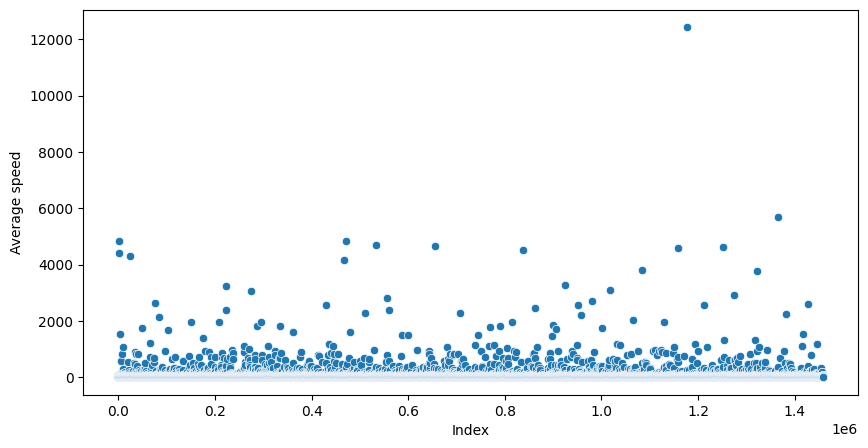

In [67]:
avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6 # Рассчет средней скорости 
fig, ax = plt.subplots(figsize=(10, 5)) # Создание фигуры и графиков
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax) # Создание точечного графика 
ax.set_xlabel('Index') # Подпись оси X
ax.set_ylabel('Average speed') # Подпись оси Y

Как раз отсюда мы видим, что у нас есть “поездки-телепортации”, для которых средняя скорость более 1000 км/ч. Даже есть такая, средняя скорость которой составляла более 12000 км/ч! 

Давайте условимся, что предельная средняя скорость, которую могут развивать таксисты будет 300 км/ч. 


### Задание 2.11.
Найдите поездки, длительность которых превышает 24 часа. И удалите их из набора данных.

а) Сколько выбросов по признаку длительности поездки вам удалось найти?

Найдите поездки, средняя скорость которых по кратчайшему пути превышает 300 км/ч и удалите их из данных. 

б) Сколько выбросов по признаку скорости вам удалось найти?

In [68]:
# ваш код здесь
print(f"Выбросов по признаку длительности поездки: {taxi_data[taxi_data['trip_duration'] / 60 / 60 > 24].shape[0]}")
taxi_data = taxi_data[taxi_data['trip_duration'] / 60 / 60 <= 24] # Удаление выбросов по признаку времени
print(f"Выбросов по признаку скорости: {taxi_data[taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6 > 300].shape[0]}")
taxi_data = taxi_data[taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6 <= 300] # Удаление выбросов по признаку скорости

Выбросов по признаку длительности поездки: 4
Выбросов по признаку скорости: 407


## 3. Разведывательный анализ данных (EDA)

В этой части нашего проекта мы с вами:
* Исследуем сформированный набор данных; 
* Попробуем найти закономерности, позволяющие сформулировать предварительные гипотезы относительно того, какие факторы являются решающими в определении длительности поездки;
* Дополним наш анализ визуализациями, иллюстрирующими; исследование. Постарайтесь оформлять диаграммы с душой, а не «для галочки»: навыки визуализации полученных выводов обязательно пригодятся вам в будущем.


Начинаем с целевого признака. Забегая вперед, скажем, что основной метрикой качества решения поставленной задачи будет RMSLE - Root Mean Squared Log Error, которая вычисляется на основе целевой переменной в логарифмическом масштабе. В таком случае целесообразно сразу логарифмировать признак длительности поездки и рассматривать при анализе логарифм в качестве целевого признака:
$$trip\_duration\_log = log(trip\_duration+1),$$
где под символом log подразумевается натуральный логарифм.


In [69]:
taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration']+1) # Создание признака логарифмированной длительности поездки 

### Задание 3.1.
Постройте гистограмму и коробчатую диаграмму длительности поездок в логарифмическом масштабе (trip_duration_log). 
Исходя из визуализации, сделайте предположение, является ли полученное распределение нормальным? 
Проверьте свою гипотезу с помощью теста Д’Агостино при уровне значимости $\alpha=0.05$. 

а) Чему равен вычисленный p-value? Ответ округлите до сотых.

б) Является ли распределение длительности поездок в логарифмическом масштабе нормальным?

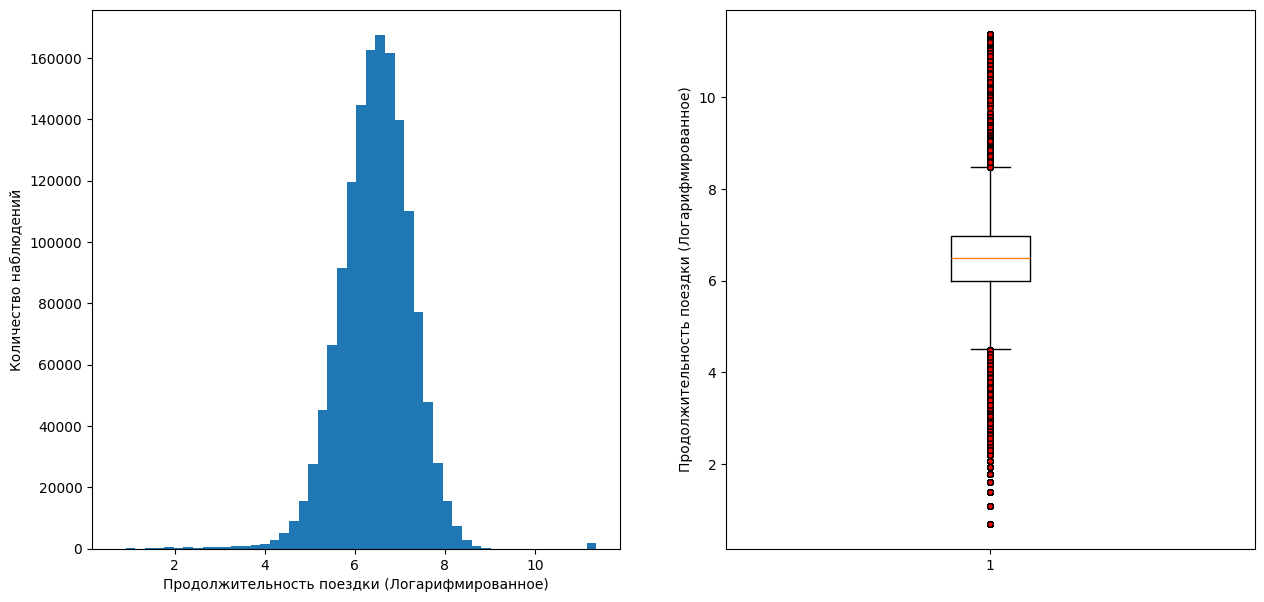

Значение p-value: 0.0, что меньше заданного значения alpha, что означает, что данные распределны не по нормальному закону


In [70]:
fig, axes = plt.subplots(1,2,figsize=(15,7)) # Создание фигуры и графиков

axes[0].hist(taxi_data['trip_duration_log'],bins=50) # Создание гистограммы
axes[0].set_xlabel('Продолжительность поездки (Логарифмированное)') # Подпись оси Х
axes[0].set_ylabel('Количество наблюдений') # Подпись оси Y

axes[1].boxplot(taxi_data['trip_duration_log'],flierprops={'markerfacecolor': 'red',
'markersize': 4, 'markeredgecolor': 'black'}) # Создание коробчатой диаграммы 
axes[1].set_ylabel('Продолжительность поездки (Логарифмированное)') # Подпись оси X 
plt.show() # Отрисовка графиков


alpha = 0.05 # Инициализацие уровня значимости 
stat, p = normaltest(taxi_data.trip_duration_log) # Тест Д’Агостино-Пирсона
print(f"Значение p-value: {p}, что меньше заданного значения alpha, что означает, что данные распределны не по нормальному закону")

### Задание 3.2.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от таксопарка (vendor_id). 

Сравните два распределения между собой.

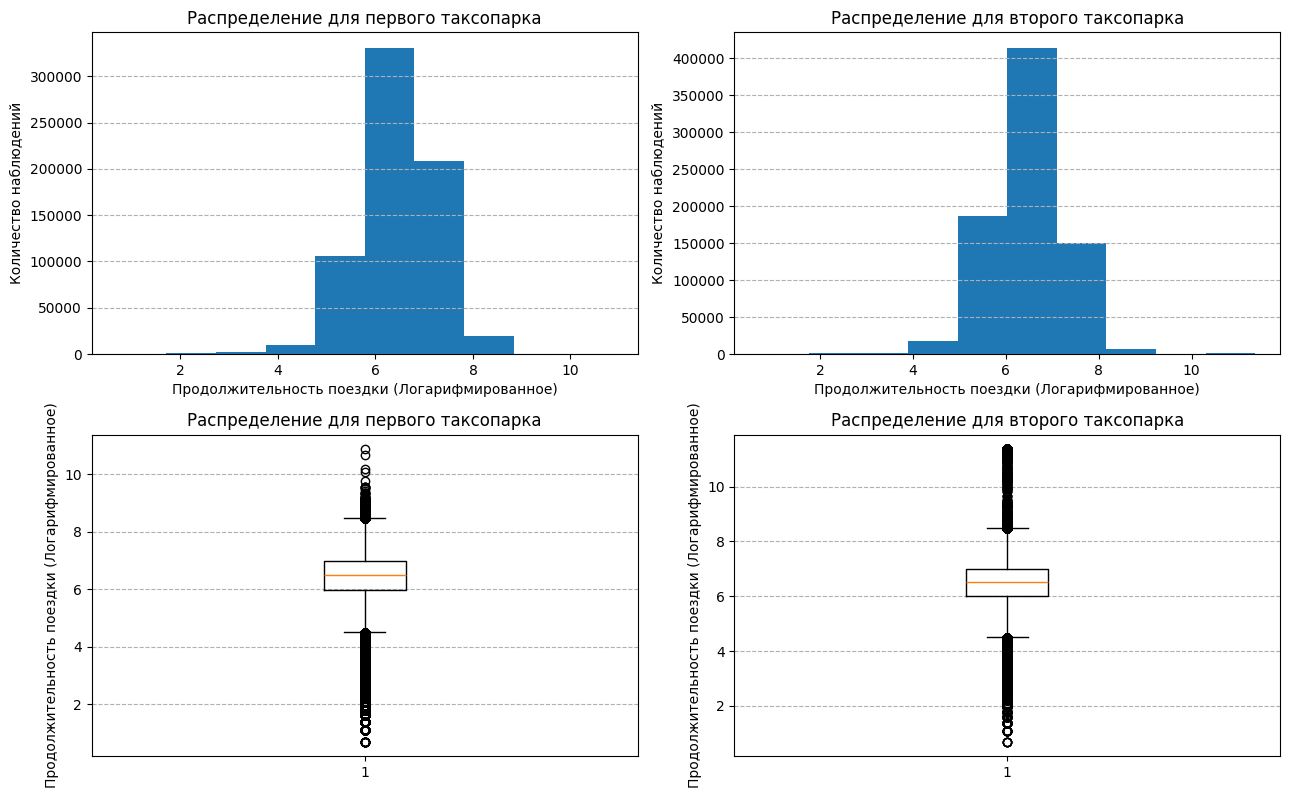

In [71]:
# ваш код здесь
vendor_1 = taxi_data[taxi_data['vendor_id'] == 1]['trip_duration_log'] # Записи для первого таксопарка 
vendor_2 = taxi_data[taxi_data['vendor_id'] == 2]['trip_duration_log'] # Записи для второго таксопарка 

fig, axes = plt.subplots(2, 2, figsize=(13, 8)) # Создание фигуры и графиков
 
axes[0,0].hist(vendor_1) # Создание гистограммы для первого таксопарка
axes[0,0].grid(axis='y', linestyle='--') # Создание сетки 
axes[0,0].set_xlabel('Продолжительность поездки (Логарифмированное)') # Подпись оси X 
axes[0,0].set_ylabel('Количество наблюдений') # Подпись оси Y 
axes[0,0].set_title('Распределение для первого таксопарка') # Подпись графика

axes[0,1].hist(vendor_2) # Создание гистограммы для второго таксопарка
axes[0,1].grid(axis='y', linestyle='--') # # Создание сетки
axes[0,1].set_xlabel('Продолжительность поездки (Логарифмированное)') # Подпись оси X 
axes[0,1].set_ylabel('Количество наблюдений') # Подпись оси Y 
axes[0,1].set_title('Распределение для второго таксопарка') # Подпись графика

axes[1,0].boxplot(vendor_1) # Создание коробчатой диаграммы для первого таксопарка
axes[1,0].grid(axis='y', linestyle='--') # Создание сетки 
axes[1,0].set_ylabel('Продолжительность поездки (Логарифмированное)') # Подпись оси Y
axes[1,0].set_title('Распределение для первого таксопарка') # Подпись графика

axes[1,1].boxplot(vendor_2) # Создание коробчатой диаграммы для второго таксопарка
axes[1,1].grid(axis='y', linestyle='--') # Создание сетки 
axes[1,1].set_ylabel('Продолжительность поездки (Логарифмированное)') # Подпись оси Y
axes[1,1].set_title('Распределение для второго таксопарка') # Подпись графика

plt.tight_layout()
plt.show() # Отрисовка графиков

### Задание 3.3.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от признака отправки сообщения поставщику (store_and_fwd_flag). 

Сравните два распределения между собой.

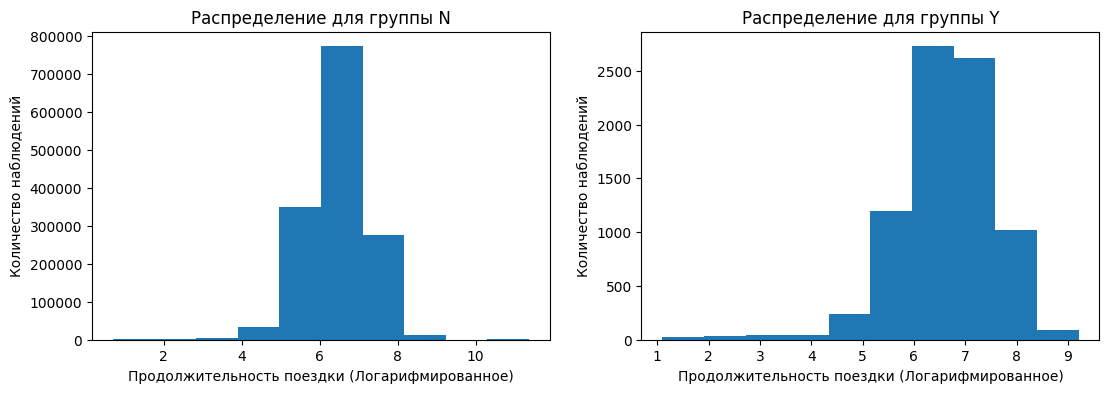

In [72]:
# ваш код здесь
flag_y = taxi_data[taxi_data['store_and_fwd_flag'] == 'Y']['trip_duration_log'] # Записи для группы Y признака отправки сообщения поставщику 
flag_n = taxi_data[taxi_data['store_and_fwd_flag'] == 'N']['trip_duration_log'] # Записи для группы N признака отправки сообщения поставщику

fig, axes = plt.subplots(1, 2, figsize=(13, 4)) # Создание фигуры и графиков

axes[0].hist(flag_n) # Создание гистограммы для группы N
axes[0].set_ylabel('Количество наблюдений') # Подпись оси Y
axes[0].set_xlabel('Продолжительность поездки (Логарифмированное)') # Подпись оси X 
axes[0].set_title('Распределение для группы N') # Подпись графика

axes[1].hist(flag_y) # Создание гистограммы для группы Y
axes[1].set_title('Распределение для группы Y')  # Подпись графика
axes[1].set_ylabel('Количество наблюдений') # Подпись оси Y
axes[1].set_xlabel('Продолжительность поездки (Логарифмированное)') # Подпись оси X

plt.show() # Отрисовка графиков

### Задание 3.4.
Постройте две визуализации:
* Распределение количества поездок в зависимости от часа дня;
* Зависимость медианной длительности поездки от часа дня.

На основе построенных графиков ответьте на следующие вопросы:

а) В какое время суток такси заказывают реже всего?

б) В какое время суток наблюдается пик медианной длительности поездок?

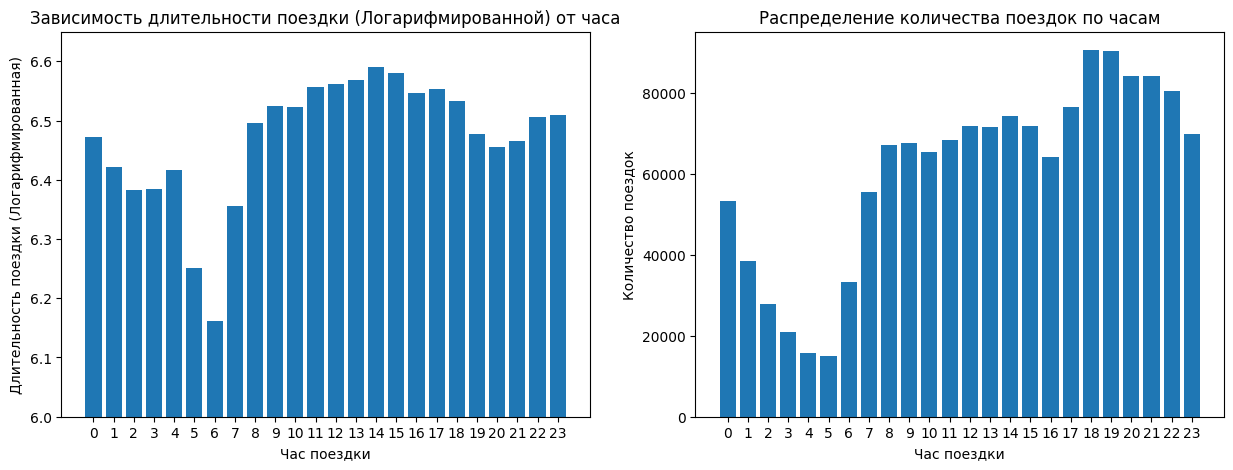

In [73]:
# ваш код здесь
median_hour = (
    taxi_data.groupby('pickup_hour')['trip_duration_log']
      .median()
      .reset_index(name='median_duration')
) # Группировка обьектов по признаку времени начала поездки 

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) # Создание фигуры и графиков

axes[0].bar(median_hour['pickup_hour'].index,median_hour['median_duration']) # Создание столбчатой диаграммы
axes[0].set_xticks(range(0, 24)) # Значение по оси X
axes[0].set_ylim(6, 6.65) # Ограничения по оси Y 
axes[0].set_xlabel('Час поездки') # Подпись оси X
axes[0].set_ylabel('Длительность поездки (Логарифмированная)') # Подпись оси Y
axes[0].set_title('Зависимость длительности поездки (Логарифмированной) от часа') # Подпись графика

axes[1].hist(taxi_data['pickup_hour'],bins=24,range=(0,24),rwidth=0.8,align='left') # Создание гистограммы 
axes[1].set_xticks(range(0, 24)) # Значение по оси X
axes[1].set_xlabel('Час поездки') # Подпись оси X 
axes[1].set_ylabel('Количество поездок') # Подпись оси Y
axes[1].set_title('Распределение количества поездок по часам') # Подпись графика
plt.show() # Отрисовка графиков

### Задание 3.5.
Постройте две визуализации:
* Распределение количества поездок в зависимости от дня недели;
*  Зависимость медианной длительности поездки от дня недели.

На основе построенных графиков ответьте на следующие вопросы:
а) В какой день недели совершается больше всего поездок?
б) В какой день недели медианная длительность поездок наименьшая?


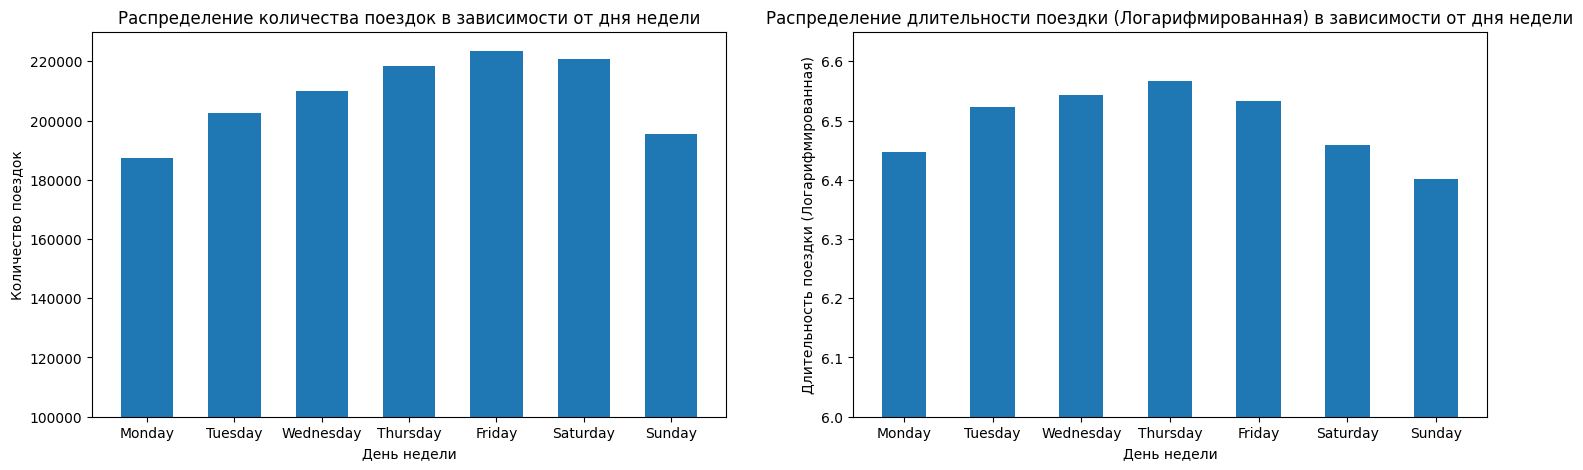

In [74]:
# ваш код здесь
counts = taxi_data['pickup_day_of_week'].value_counts().sort_index() # Подсчет значений дней поездки

count_days = taxi_data.groupby('pickup_day_of_week')['trip_duration_log'].median().reset_index(name='median_duration') # Группировка по признаку значений дня поездки
count_days = pd.DataFrame(count_days) # Создание датафрейма для удобства

labels=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'] # Список названий дней недели

fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Создание фигуры и графиков

axes[0].bar(counts.index, counts.values, width=0.6 ,align='center') # Создание столбчатой диаграммы
axes[0].set_xticks(ticks=counts.index,labels=labels) # Значение по оси X
axes[0].set_ylim(100000, 230000) # Ограничения по оси Y
axes[0].set_xlabel('День недели') # Подпись оси X 
axes[0].set_ylabel('Количество поездок') # Подпись оси Y
axes[0].set_title('Распределение количества поездок в зависимости от дня недели') # Подпись графика

axes[1].bar(count_days['pickup_day_of_week'],height=count_days['median_duration'], width=0.5) # Создание столбчатой диаграммы
axes[1].set_xticks(ticks=counts.index,labels=labels) # Значение по оси X
axes[1].set_ylim(6, 6.65) # Ограничения по оси Y
axes[1].set_xlabel('День недели') # Подпись оси X 
axes[1].set_ylabel('Длительность поездки (Логарифмированная)') # Подпись оси Y
axes[1].set_title('Распределение длительности поездки (Логарифмированная) в зависимости от дня недели') # Подпись графика

plt.show() # Отрисовка графиков

### Задание 3.6.
Посмотрим на обе временные характеристики одновременно. 

Постройте сводную таблицу, по строкам которой отложены часы (pickup_hour), по столбцам - дни недели (pickup_day_of_week), а в ячейках - медианная длительность поездки (trip_duration). 

Визуализируйте полученную сводную таблицу с помощью тепловой карты (рекомендуемая палитра - coolwarm).

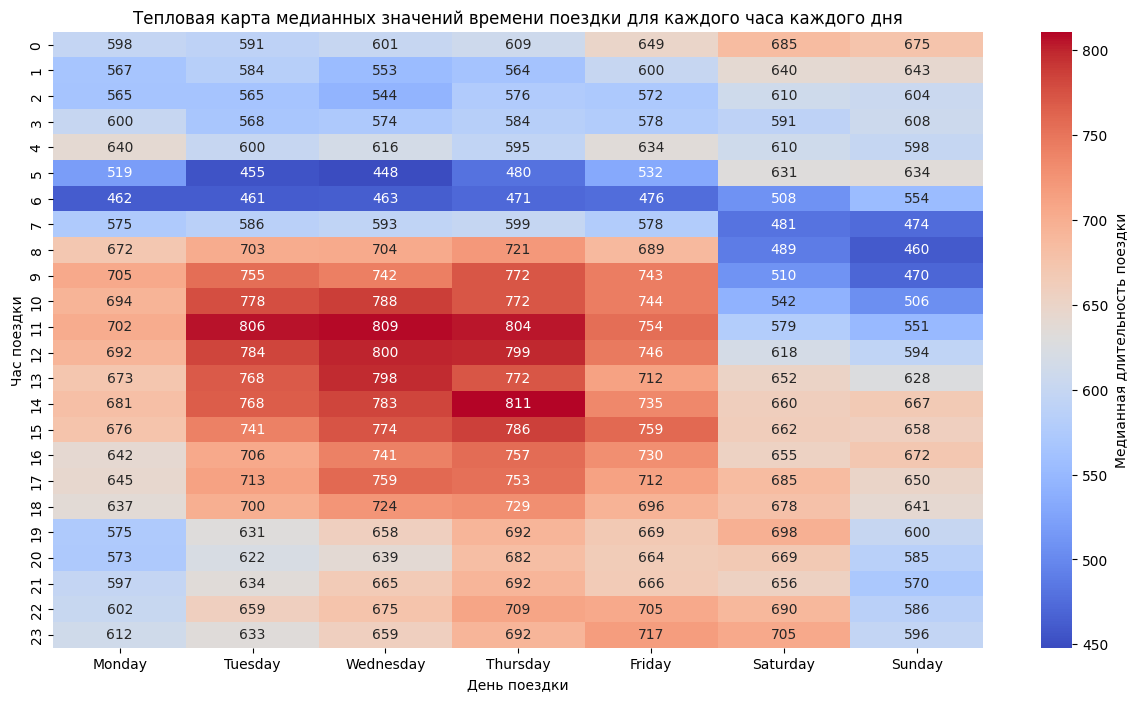

In [75]:
# ваш код здесь
hour_day_data = pd.pivot_table(taxi_data,
                               index='pickup_hour',
                               columns='pickup_day_of_week',
                               values='trip_duration',
                               aggfunc='median') # Создание таблицы с медианными значениями длительности поездки для каждого дня и часа поездки

figure = plt.figure(figsize=(15,8)) # Создание фигуры

sns.heatmap(hour_day_data,
            annot=True,
            cmap='coolwarm',
            fmt='.0f',
            cbar_kws={"label": "Медианная длительность поездки"},
            xticklabels=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']) # Создание тепловой карты 
plt.xlabel('День поездки') # Подпись оси X
plt.ylabel('Час поездки') # Подпись оси Y
plt.title('Тепловая карта медианных значений времени поездки для каждого часа каждого дня') # Подпись графика
plt.show() # Отрисовка графиков

### Задание 3.7.
Постройте две диаграммы рассеяния (scatter-диаграммы):
* первая должна иллюстрировать географическое расположение точек начала поездок (pickup_longitude, pickup_latitude) 
* вторая должна географическое расположение точек завершения поездок (dropoff_longitude, dropoff_latitude).

Для этого на диаграммах по оси абсцисс отложите широту (longitude), а по оси ординат - долготу (latitude). 
Включите в визуализацию только те точки, которые находятся в пределах Нью-Йорка - добавьте следующие ограничения на границы осей абсцисс и ординат:
 
city_long_border = (-74.03, -73.75)

city_lat_border = (40.63, 40.85)

Добавьте на диаграммы расцветку по десяти географическим кластерам (geo_cluster), которые мы сгенерировали ранее. 

**Рекомендация:** для наглядности уменьшите размер точек на диаграмме рассеяния.  


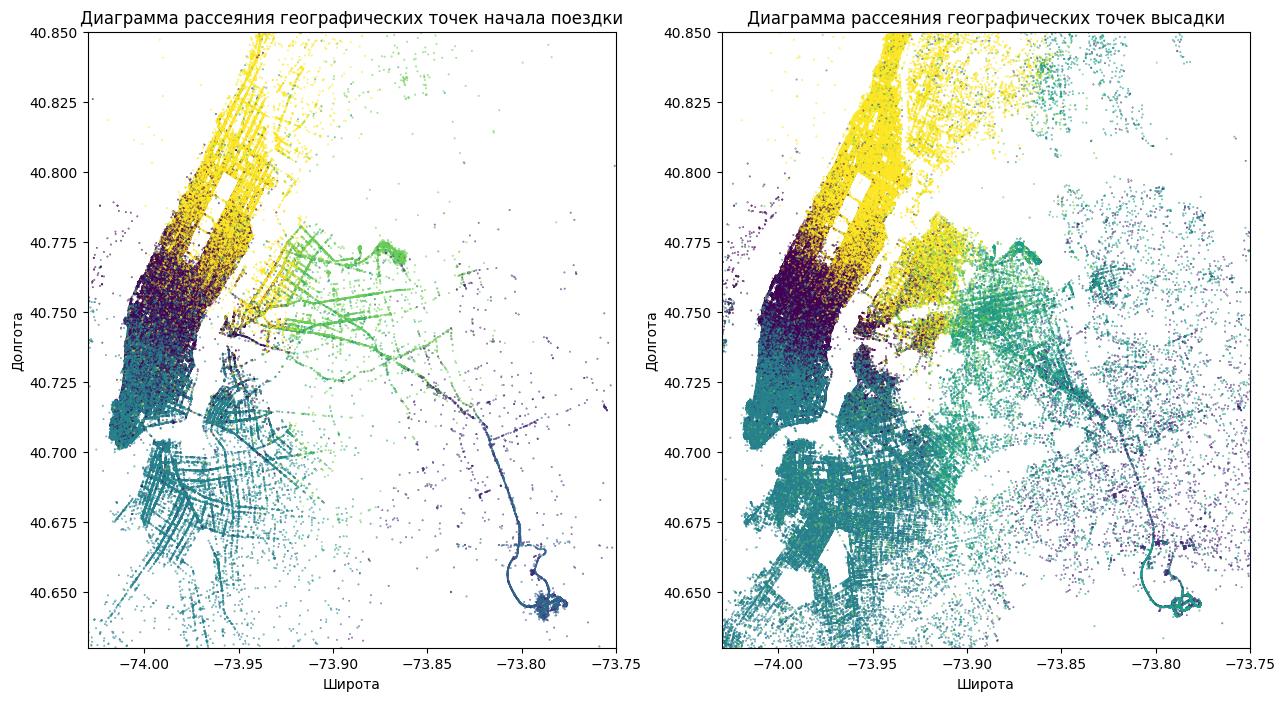

In [76]:
city_long_border = (-74.03, -73.75) # Граница широты 
city_lat_border = (40.63, 40.85) # Граница долготы
# ваш код здесь
figure, axes = plt.subplots(1, 2, figsize=(15,8)) # Создание фигуры и графиков

axes[0].scatter(x=taxi_data['pickup_longitude'], y=taxi_data['pickup_latitude'], c=taxi_data['geo_cluster'], s=0.1) # Создание точечного графика
axes[0].set_xlim(city_long_border) # Ограничения по оси X
axes[0].set_ylim(city_lat_border) # Ограничения по оси Y
axes[0].set_xlabel('Широта') # Подпись оси X
axes[0].set_ylabel('Долгота') # Подпись оси Y
axes[0].set_title('Диаграмма рассеяния географических точек начала поездки') # Подпись графика

axes[1].scatter(x=taxi_data['dropoff_longitude'], y=taxi_data['dropoff_latitude'], c=taxi_data['geo_cluster'], s=0.1) # Создание точечного графика
axes[1].set_xlim(city_long_border) # Ограничения по оси X
axes[1].set_ylim(city_lat_border) # Ограничения по оси Y
axes[1].set_xlabel('Широта') # Подпись оси X
axes[1].set_ylabel('Долгота') # Подпись оси Y
axes[1].set_title('Диаграмма рассеяния географических точек высадки') # Подпись графика

plt.show() # Отрисовка графиков

## 4. Отбор и преобразование признаков

Перед тем как перейти к построению модели, осталось сделать ещё несколько шагов.
* Следует помнить, что многие алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. Поэтому нам необходимо их закодировать;
* Надо отобрать признаки, которые мы будем использовать для обучения модели;
*  Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить сходимость моделей, в основе которых лежат численные методы.


In [77]:
print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


Для удобства работы сделаем копию исходной таблицы с поездками:

In [78]:
train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5.0,1.498521,99.970196,9,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6.0,1.805507,-117.153768,4,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16.0,6.385098,-159.680165,4,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4.0,1.485498,-172.737700,4,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5.0,1.188588,179.473585,9,9.4,16.1,9.3,0.0,None,6.077642


### Задание 4.1.
Сразу позаботимся об очевидных неинформативных и избыточных признаках. 

а) Какой из признаков является уникальным для каждой поездки и не несет полезной информации в определении ее продолжительности?

б) Утечка данных (data leak) - это…

в) Подумайте, наличие какого из признаков в обучающем наборе данных создает утечку данных?

г) Исключите выбранные в пунктах а) и в) признаки из исходной таблицы с данными. Сколько столбцов в таблице у вас осталось?


In [79]:
# ваш код здесь
train_data = train_data.drop(['id','dropoff_datetime'],axis=1) # Удаление ненужных столбцов

Ранее мы извлекли всю необходимую для нас информацию из даты начала поездки, теперь мы можем избавиться от этих признаков, так как они нам больше не понадобятся:


In [80]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


### Задание 4.2.

Закодируйте признак vendor_id в таблице train_data таким образом, чтобы он был равен 0, если идентификатор таксопарка равен 1, и 1 — в противном случае.

Закодируйте признак store_and_fwd_flag в таблице train_data таким образом, чтобы он был равен 0, если флаг выставлен в значение 'N', и 1 — в противном случае.

а) Рассчитайте среднее по закодированному столбцу vendor_id. Ответ приведите с точностью до сотых.

б) Рассчитайте среднее по закодированному столбцу store_and_fwd_flag. Ответ приведите с точностью до тысячных.



In [81]:
# ваш код здесь
train_data['vendor_id'] = train_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1) # Кодирование категориального признака 
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1) # Кодирование категориального признака

In [82]:
print(f"Среднее по закодированному столбцу vendor_id: {train_data['vendor_id'].mean():.2f}")
print(f"Cреднее по закодированному столбцу store_and_fwd_flag: {train_data['store_and_fwd_flag'].mean():.3f}")

Среднее по закодированному столбцу vendor_id: 0.53
Cреднее по закодированному столбцу store_and_fwd_flag: 0.006


### Задание 4.3.
Создайте таблицу data_onehot из закодированных однократным кодированием признаков pickup_day_of_week, geo_cluster и events в таблице train_data с помощью OneHotEncoder из библиотеки sklearn. Параметр drop выставите в значение 'first', чтобы удалять первый бинарный столбец, тем самым не создавая излишних признаков.

В параметре handle_unknown установите значение 'ignore'. Это позволит коду отработать без ошибок в случае появления в тестовой выборке значений, отсутствующих в обучающей выборке.

В результате работы OneHotEncoder вы получите безымянный numpy-массив, который нам будет необходимо преобразовать обратно в DataFrame, для более удобной работы в дальнейшем. Чтобы получить имена закодированных столбцов у объекта типа OneHotEncoder есть специальный метод get_feature_names_out(). Он возвращает список новых закодированных имен столбцов в формате <оригинальное имя столбца>_<имя категории>.

Пример использования:

``` python
# Объявляем кодировщик
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out()
# Составляем DataFrame из закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
```

В этом псевдокоде:
* one_hot_encoder - объект класса OneHotEncoder
* data_onehot - numpy-массив, полученный в результате трансформации кодировщиком

В результате выполнения задания у вас должен быть образован DataFrame `data_onehot`, который содержит кодированные категориальные признаки pickup_day_of_week, geo_cluster и events. 


Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования?


In [83]:
# ваш код здесь
columns_to_change = ['pickup_day_of_week', 'geo_cluster', 'events'] # Столбцы для кодирования
one_hot_encoder = OneHotEncoder(drop='first',handle_unknown='ignore') # Объявляем кодировщик
data_onehot = one_hot_encoder.fit_transform(train_data[columns_to_change]) # Преобразование
column_names = one_hot_encoder.get_feature_names_out() # Вывод закодированных столбцов
data_onehot = data_onehot.toarray() # Преобразование в массив 
data_onehot = pd.DataFrame(data_onehot,columns=column_names) # Составляем DataFrame из закодированных признаков
data_onehot

,pickup_day_of_week_1,pickup_day_of_week_2,pickup_day_of_week_3,pickup_day_of_week_4,pickup_day_of_week_5,pickup_day_of_week_6,geo_cluster_1,geo_cluster_2,geo_cluster_3,geo_cluster_4,geo_cluster_5,geo_cluster_6,geo_cluster_7,geo_cluster_8,geo_cluster_9,events_None,events_Rain,events_Snow
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458228,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1458229,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1458230,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1458231,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Добавим полученную таблицу с закодированными признаками:

In [84]:
train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(columns_to_change, axis=1), data_onehot], 
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


In [85]:
train_data = train_data.astype('float32') # Преобразование данных в тип Float32 для экономии памяти

Теперь, когда категориальные признаки предобработаны, сформируем матрицу наблюдений X, вектор целевой переменной y и его логарифм y_log. В матрицу наблюдений войдут все столбцы из таблицы с поездками за исключением целевого признака trip_duration и его логарифмированной версии trip_duration_log:


In [86]:
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

Все наши модели мы будем обучать на логарифмированной версии y_log. 

Выбранный тип валидации - hold-out. Разобьем выборку на обучающую и валидационную в соотношении 67/33:

In [87]:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log, 
    test_size=0.33, 
    random_state=42
)

На данный момент у нас достаточно много признаков: скорее всего, не все из них будут важны. Давайте оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.


### Задание 4.4.
С помощью SelectKBest отберите 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе. Отбор реализуйте по обучающей выборке, используя параметр score_func = f_regression.

Укажите признаки, которые вошли в список отобранных


In [ ]:
# ваш код здесь
selector = SelectKBest(score_func=f_regression, k=25) # Объявление алгоритма отбора наиболее важных признаков
X_train_new = selector.fit_transform(X_train,y_train_log) # Отбор признаков 
mask = selector.get_support()
selected_features = X_train.columns[mask] # Объявление переменной со списком самых важных признаков
print(selected_features)


Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'pickup_hour', 'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'temperature',
       'pickup_day_of_week_1', 'pickup_day_of_week_2', 'pickup_day_of_week_3',
       'pickup_day_of_week_4', 'pickup_day_of_week_5', 'pickup_day_of_week_6',
       'geo_cluster_1', 'geo_cluster_3', 'geo_cluster_5', 'geo_cluster_7',
       'geo_cluster_9'],
      dtype='object')


Так как мы будем использовать различные модели, в том числе внутри которых заложены численные методы оптимизации, то давайте заранее позаботимся о масштабировании факторов. 


### Задание 4.5.
Нормализуйте предикторы в обучающей и валидационной выборках с помощью MinMaxScaler из библиотеки sklearn. Помните, что обучение нормализатора производится на обучающей выборке, а трансформация на обучающей и валидационной!

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из валидационной выборки. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
scaler = MinMaxScaler().fit(X_train[selected_features]) # Объявление кодировщика
X_train_scaled = scaler.transform(X_train[selected_features]) # Преобразование данных
X_valid_scaled = scaler.transform(X_valid[selected_features]) # Преобразование данных
print(f"Среднее арифмитическое для первого предиктора: {X_valid_scaled[:,0].mean():.2f}")

0.54

## 5. Решение задачи регрессии: линейная регрессия и деревья решений

Определим метрику, по которой мы будем измерять качество наших моделей. Мы будем следовать канонам исходного соревнования на Kaggle и в качестве метрики использовать RMSLE (Root Mean Squared Log Error), которая вычисляется как:
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная длительность i-ой поездки на такси (trip_duration)
* $\hat{y_i}$- предсказанная моделью длительность i-ой поездки на такси

Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать длительность поездки такси в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$



### Задание 5.1.
Постройте модель линейной регрессии на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
LR = LinearRegression() # Объявление алгоритма линейной регрессии 
LR.fit(X_train_scaled,y_train_log) # Обучение алгоритма на тренировочных данных

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(LR.predict(X_train_scaled),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(LR.predict(X_valid_scaled),y_valid_log)):.2f}')

RMSLE на тренировочной выборке: 0.54
RMSLE на валидационной выборке: 0.54


### Задание 5.2.
Сгенерируйте полиномиальные признаки 2-ой степени с помощью PolynomialFeatures из библиотеки sklearn. Параметр include_bias выставите в значение False.

Постройте модель полиномиальной регрессии 2-ой степени на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [ ]:
# ваш код здесь
poly = PolynomialFeatures(include_bias=False).fit(X_train_scaled) # Объявление и обучение генератора полиномиальных признаков

X_train_scaled_poly = poly.transform(X_train_scaled) # Преобразование данных
X_valid_scaled_poly = poly.transform(X_valid_scaled) # Преобразование данных
 
LR1 = LinearRegression().fit(X_train_scaled_poly, y_train_log) # Обучение алгоритма линейной регрессии на тренировочных данных с полиномиальными признаками

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(LR1.predict(X_train_scaled_poly),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(LR1.predict(X_valid_scaled_poly),y_valid_log)):.2f}')


RMSLE на тренировочной выборке: 0.47
RMSLE на валидационной выборке: 0.54


### Задание 5.3.
Постройте модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке  (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Коэффициент регуляризации $\alpha$ установите равным 1, остальные параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
RLR = Ridge(alpha=1).fit(X_train_scaled_poly, y_train_log) # Объявление и обучение линейной регрессии с L2 регуляризации на тренировочных данных с полиномиальными признаками

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(RLR.predict(X_train_scaled_poly),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(RLR.predict(X_valid_scaled_poly),y_valid_log)):.2f}')


RMSLE на тренировочной выборке: 0.48
RMSLE на валидационной выборке: 0.48


### Задание 5.4.
Постройте модель дерева решений (DecisionTreeRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию. 

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [ ]:
# ваш код здесь
DT = DecisionTreeRegressor().fit(X_train_scaled, y_train_log) # Объявление и обучение дерева решений на тренировочных данных

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(DT.predict(X_train_scaled),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(DT.predict(X_valid_scaled),y_valid_log)):.2f}')

RMSLE на тренировочной выборке: 0.00
RMSLE на валидационной выборке: 0.57


### Задание 5.5.
Переберите все возможные варианты глубины дерева решений в диапазоне от 7 до 20:

max_depths = range(7, 20)

Параметр random_state задайте равным 42.

Постройте линейные графики изменения метрики RMSE на тренировочной и валидационной выборках в зависимости от значения параметра глубины дерева решений. 

а) Найдите оптимальное значение максимальной глубины дерева, для которой будет наблюдаться минимальное значение RMSLE на обучающей выборке, но при этом еще не будет наблюдаться переобучение (валидационная кривая еще не начинает возрастать).

б) Чему равно значение метрик RMSLE на тренировочной и валидационной выборках для дерева решений с выбранной оптимальной глубиной? Ответ округлите до сотых.


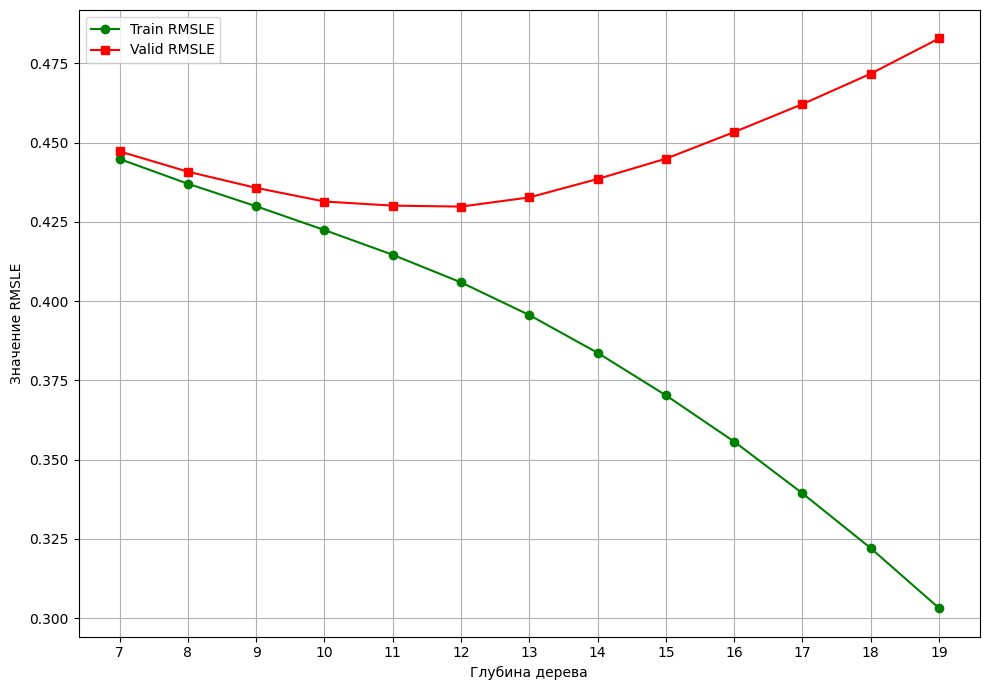

In [ ]:
# ваш код здесь
scores_train = [] # Создание списка для сохранения метрик на тренировочной выборке
scores_valid = [] # Создание списка для сохранения метрик на валидационной выборке
max_depths = range(7,20) # Создание диапазона ограничения максимальной глубины дерева

for i in range(7,20): # Создание цикла 
    DT = DecisionTreeRegressor(random_state=42, max_depth=i).fit(X_train_scaled,y_train_log) # Создание и обучение дерева решений на тренировочных данных с текущей глубиной дерева
    scores_train.append(round(np.sqrt(mean_squared_error(DT.predict(X_train_scaled),y_train_log)),4)) # Добавление значения метрики в список
    scores_valid.append(round(np.sqrt(mean_squared_error(DT.predict(X_valid_scaled),y_valid_log)),4)) # Добавление значения метрики в список
    
plt.figure(figsize=(10, 7)) # Создание фигуры и графиков
plt.plot(max_depths, scores_train, color='green', marker='o', label='Train RMSLE') # Создание графика значений метрики для тренировочных данных
plt.plot(max_depths, scores_valid, color='red', marker='s', label='Valid RMSLE') # Создание графика значений метрики для валидационных данных
plt.xticks(max_depths) # Значения по оси X 
plt.xlabel('Глубина дерева') # Подпись оси X 
plt.ylabel('Значение RMSLE') # Подпись оси Y
plt.legend(loc='best') # Создание легенды 
plt.grid() # Создание сетки 
plt.tight_layout() 
plt.show() # Отображение графика

In [ ]:
scores = {'scores_train': scores_train, 'scores_valid': scores_valid} # Создание словаря с метриками
scores = pd.DataFrame(data=scores,index=range(7,20)) # Создание датафрейма для удобства 

print(f"Оптимальная глубина дерева: {scores[scores['scores_valid'] == scores['scores_valid'].min()].index[0]}")
print(f"RMSLE на тренировочной выборке с оптимальной глубиной дерева: {scores.loc[12][0]:.2f}") 
print(f"RMSLE на валидационной выборке с оптимальной глубиной дерева: {scores.loc[12][1]:.2f}") 

Оптимальная глубина дерева: 12
RMSLE на тренировочной выборке с оптимальной глубиной дерева: 0.41
RMSLE на валидационной выборке с оптимальной глубиной дерева: 0.43


## 6. Решение задачи регрессии: ансамблевые методы и построение прогноза

Переходим к тяжелой артиллерии: ансамблевым алгоритмам. 

### Задание 6.1.

Постройте модель случайного леса на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* n_estimators=200,
* max_depth=12,
* criterion='squared_error',
* min_samples_split=20,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [ ]:
# ваш код здесь
RF = RandomForestRegressor(n_estimators=200,
                           max_depth=12,
                           criterion='squared_error',
                           min_samples_split=20,
                           random_state=42,
                           n_jobs=-1) # Создание ансамблевой модели случайного леса

RF.fit(X_train_scaled, y_train_log) # Обучение модели

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(RF.predict(X_train_scaled),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(RF.predict(X_valid_scaled),y_valid_log)):.2f}')

RMSLE на тренировочной выборке: 0.40
RMSLE на валидационной выборке: 0.41


### Задание 6.2.
Постройте модель градиентного бустинга над деревьями решений (GradientBoostingRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* learning_rate=0.5,
* n_estimators=100,
* max_depth=6, 
* min_samples_split=30,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [97]:
# ваш код здесь
GBR = GradientBoostingRegressor(learning_rate=0.5,
                                 n_estimators=100,
                                 max_depth=6, 
                                 min_samples_split=30,
                                 random_state=42) # Создание ансамблевой модели градиентного бустинга

GBR.fit(X_train_scaled, y_train_log) # Обучение модели

print(f'RMSLE на тренировочной выборке: {np.sqrt(mean_squared_error(GBR.predict(X_train_scaled),y_train_log)):.2f}')
print(f'RMSLE на валидационной выборке: {np.sqrt(mean_squared_error(GBR.predict(X_valid_scaled),y_valid_log)):.2f}')

RMSLE на тренировочной выборке: 0.37
RMSLE на валидационной выборке: 0.39


### Задание 6.3.
Какая из построенных вами моделей показала наилучший результат (наименьшее значение RMSLE на валидационной выборке)?
* Линейная регрессия
* Полиномиальная регрессия 2ой степени
* Дерево решений
* Случайный лес
* Градиентный бустинг над деревьями решений


### Задание 6.4.
Постройте столбчатую диаграмму коэффициентов значимости каждого из факторов.

Укажите топ-3 наиболее значимых для предсказания целевого признака - длительности поездки в логарифмическом масштабе - факторов.


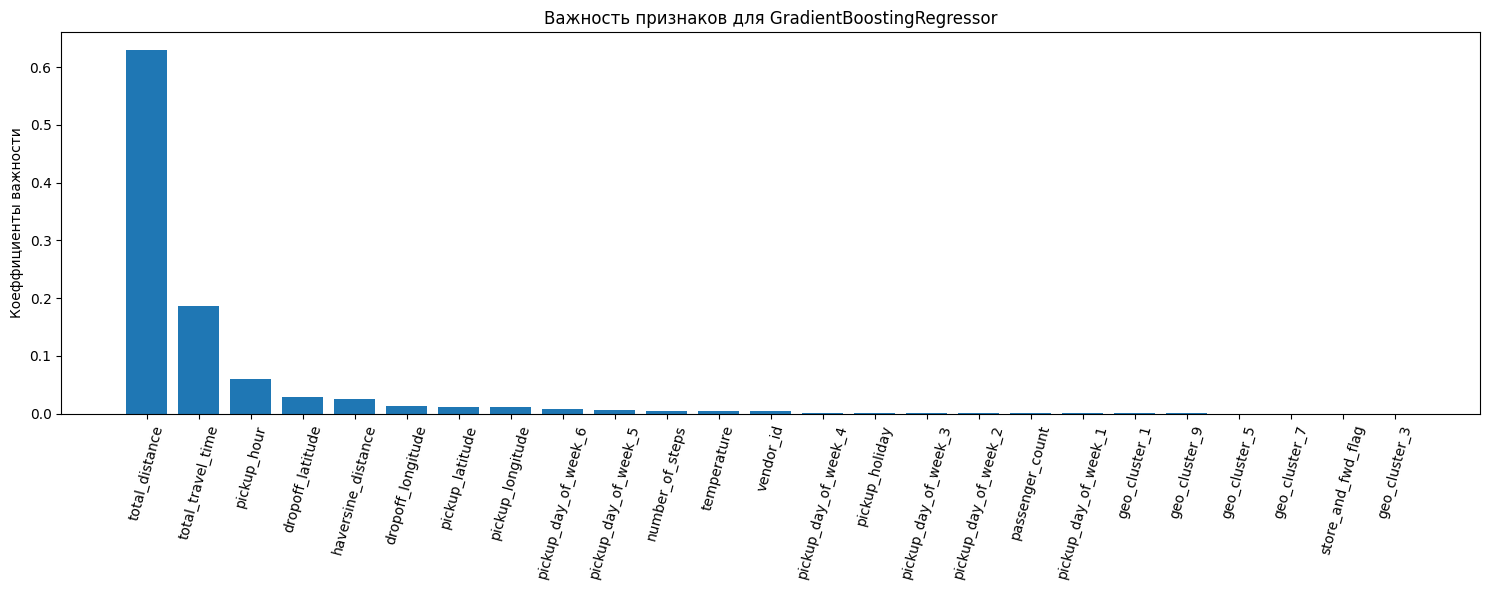

In [98]:
# ваш код здесь
importances = GBR.feature_importances_ # Получение коеффициентов важности признаков
indices = np.argsort(importances)[::-1] # Сортировка и получение индексов коеффициентов важности признаков

plt.figure(figsize=(15, 6)) # Создание фигуры 
plt.title("Важность признаков для GradientBoostingRegressor") # Подпись графика
plt.bar(selected_features[indices], importances[indices], align="center") # Создание столбчатого графика
plt.xticks(ticks=selected_features, rotation=75) # Значения по оси Х
plt.ylabel('Коеффициенты важности') # Значения по оси Y
plt.tight_layout()
plt.show() # Отрисовка графика

### Задание 6.5.
Для лучшей из построенных моделей рассчитайте медианную абсолютную ошибку (MeAE - в sklearn функция median_absolute_error) предсказания длительности поездки такси на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

Значение метрики MeAE переведите в минуты и округлите до десятых.


In [ ]:
# ваш код здесь
y_valid = np.exp(y_valid_log) - 1 # Преобразование логарифмированного признака в обычный 
print(f'MeAE в минутах на валидационной выборке: {median_absolute_error(np.exp(GBR.predict(X_valid_scaled)) - 1, y_valid) / 60:.2f}')

MeAE в минутах на валидационной выборке: 1.84


Финальный шаг - сделать submit -  предсказание для отложенного тестового набора данных. 

Прочитаем тестовые данные и заранее выделим столбец с идентификаторами поездок из тестового набора данных. Он нам еще пригодится:


In [100]:
test_data = pd.read_csv("D:/IDE/data/test_data.csv")
osrm_data_test = pd.read_csv("D:/IDE/data/osrm_data_test.csv")
test_id = test_data['id']

Перед созданием прогноза для тестовой выборки необходимо произвести все манипуляции с данными, которые мы производили с тренировочной выборкой, а именно:
* Перевести признак pickup_datetime в формат datetime;
* Добавить новые признаки (временные, географические, погодные и другие факторы);
* Произвести очистку данных от пропусков;
* Произвести кодировку категориальных признаков:
    * Закодировать бинарные признаки;
    * Закодировать номинальные признаки с помощью обученного на тренировочной выборке OneHotEncoder’а;
* Сформировать матрицу наблюдений, оставив в таблице только те признаки, которые были отобраны с помощью SelectKBest;
* Нормализовать данные с помощью обученного на тренировочной выборке MinMaxScaler’а.


In [ ]:
test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S') 
test_data = add_datetime_features(test_data)
test_data = add_holiday_features(test_data, holiday_data)
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_cluster_features(test_data, kmeans)
test_data = add_weather_features(test_data, weather_data)
test_data = fill_null_weather_data(test_data)

test_data['vendor_id'] = test_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
test_data_onehot = one_hot_encoder.fit_transform(test_data[columns_to_change]).toarray()
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

test_data = pd.concat(
    [test_data.reset_index(drop=True).drop(columns_to_change, axis=1), test_data_onehot], 
    axis=1
)
X_test = test_data[selected_features]
X_test_scaled = scaler.transform(X_test)
print('Shape of data: {}'.format(X_test.shape))

Shape of data: (625134, 25)


Только после выполнения всех этих шагов можно сделать предсказание длительности поездки для тестовой выборки. Не забудьте перевести предсказания из логарифмического масштаба в истинный, используя формулу:
$$y_i=exp(z_i)-1$$

После того, как вы сформируете предсказание длительности поездок на тестовой выборке вам необходимо будет создать submission-файл в формате csv, отправить его на платформу Kaggle и посмотреть на результирующее значение метрики RMSLE на тестовой выборке.

Код для создания submission-файла:


In [103]:
# ваш код здесь
y_test_predict = np.exp(GBR.predict(X_test_scaled)) - 1
submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_predict})
submission.to_csv('D:/IDE/data/submission_gb.csv', index=False)

### **В качестве бонуса**

В завершение по ансамблевым мы предлагаем вам попробовать улучшить свое предсказание, воспользовавшись моделью экстремального градиентного бустинга (XGBoost) из библиотеки xgboost.

**XGBoost** - современная модель машинного обучения, которая является продолжением идеи градиентного бустинга Фридмана. У нее есть несколько преимуществ по сравнению с классической моделью градиентного бустинга из библиотеки sklearn: повышенная производительность путем параллелизации процесса обучения, повышенное качество решения за счет усовершенствования алгоритма бустинга, меньшая склонность к переобучению и широкий функционал возможности управления параметрами модели.


Для ее использования необходимо для начала установить пакет xgboost:

После чего модуль можно импортировать:

In [ ]:
import xgboost as xgb

Перед обучением модели необходимо перевести наборы данных в тип данных xgboost.DMatrix:

In [ ]:
# Создание матриц наблюдений в формате DMatrix
dtrain = xgb.DMatrix(X_train_scaled, label=y_train_log, feature_names=list(selected_features))
dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid_log, feature_names=list(selected_features))
dtest = xgb.DMatrix(X_test_scaled, feature_names=list(selected_features))

Обучение модели XGBoost происходит с помощью метода train, в который необходимо передать параметры модели, набор данных, количество базовых моделей в ансамбле, а также дополнительные параметры:


In [ ]:
# Гиперпараметры модели
xgb_pars = {'min_child_weight': 20, 'eta': 0.1, 'colsample_bytree': 0.9, 
            'max_depth': 6, 'subsample': 0.9, 'lambda': 1, 'nthread': -1, 
            'booster' : 'gbtree', 'eval_metric': 'rmse', 'objective': 'reg:squarederror'
           }
# Тренировочная и валидационная выборка
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]
# Обучаем модель XGBoost
model = xgb.train(
    params=xgb_pars, #гиперпараметры модели
    dtrain=dtrain, #обучающая выборка
    num_boost_round=300, #количество моделей в ансамбле
    evals=watchlist, #выборки, на которых считается матрица
    early_stopping_rounds=20, #раняя остановка
    maximize=False, #смена поиска максимума на минимум
    verbose_eval=10 #шаг, через который происходит отображение метрик
)

[0]	train-rmse:0.73992	valid-rmse:0.74194
[10]	train-rmse:0.49099	valid-rmse:0.49359
[20]	train-rmse:0.44099	valid-rmse:0.44383
[30]	train-rmse:0.42671	valid-rmse:0.42969
[40]	train-rmse:0.41891	valid-rmse:0.42210
[50]	train-rmse:0.41341	valid-rmse:0.41686
[60]	train-rmse:0.40976	valid-rmse:0.41351
[70]	train-rmse:0.40644	valid-rmse:0.41060
[80]	train-rmse:0.40377	valid-rmse:0.40816
[90]	train-rmse:0.40163	valid-rmse:0.40632
[100]	train-rmse:0.40001	valid-rmse:0.40505
[110]	train-rmse:0.39859	valid-rmse:0.40388
[120]	train-rmse:0.39747	valid-rmse:0.40304
[130]	train-rmse:0.39591	valid-rmse:0.40177
[140]	train-rmse:0.39506	valid-rmse:0.40113
[150]	train-rmse:0.39387	valid-rmse:0.40019
[160]	train-rmse:0.39308	valid-rmse:0.39967
[170]	train-rmse:0.39238	valid-rmse:0.39928
[180]	train-rmse:0.39164	valid-rmse:0.39875
[190]	train-rmse:0.39081	valid-rmse:0.39819
[200]	train-rmse:0.39014	valid-rmse:0.39784
[210]	train-rmse:0.38953	valid-rmse:0.39757
[220]	train-rmse:0.38866	valid-rmse:0.39703

Предсказать целевой признак на новых данных можно с помощью метода predict():

In [ ]:
#Делаем предсказание на тестовом наборе данных
y_test_predict = np.exp(model.predict(dtest)) - 1
print('Modeling RMSLE %.5f' % model.best_score)

Modeling RMSLE 0.39447


Также как и все модели, основанные на использовании деревьев решений в качестве базовых моделей, XGBoost имеет возможность определения коэффициентов важности факторов. Более того, в библиотеку встроена возможность визуализации важность факторов в виде столбчатой диаграммы. За эту возможность отвечает функция plot_importance():


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

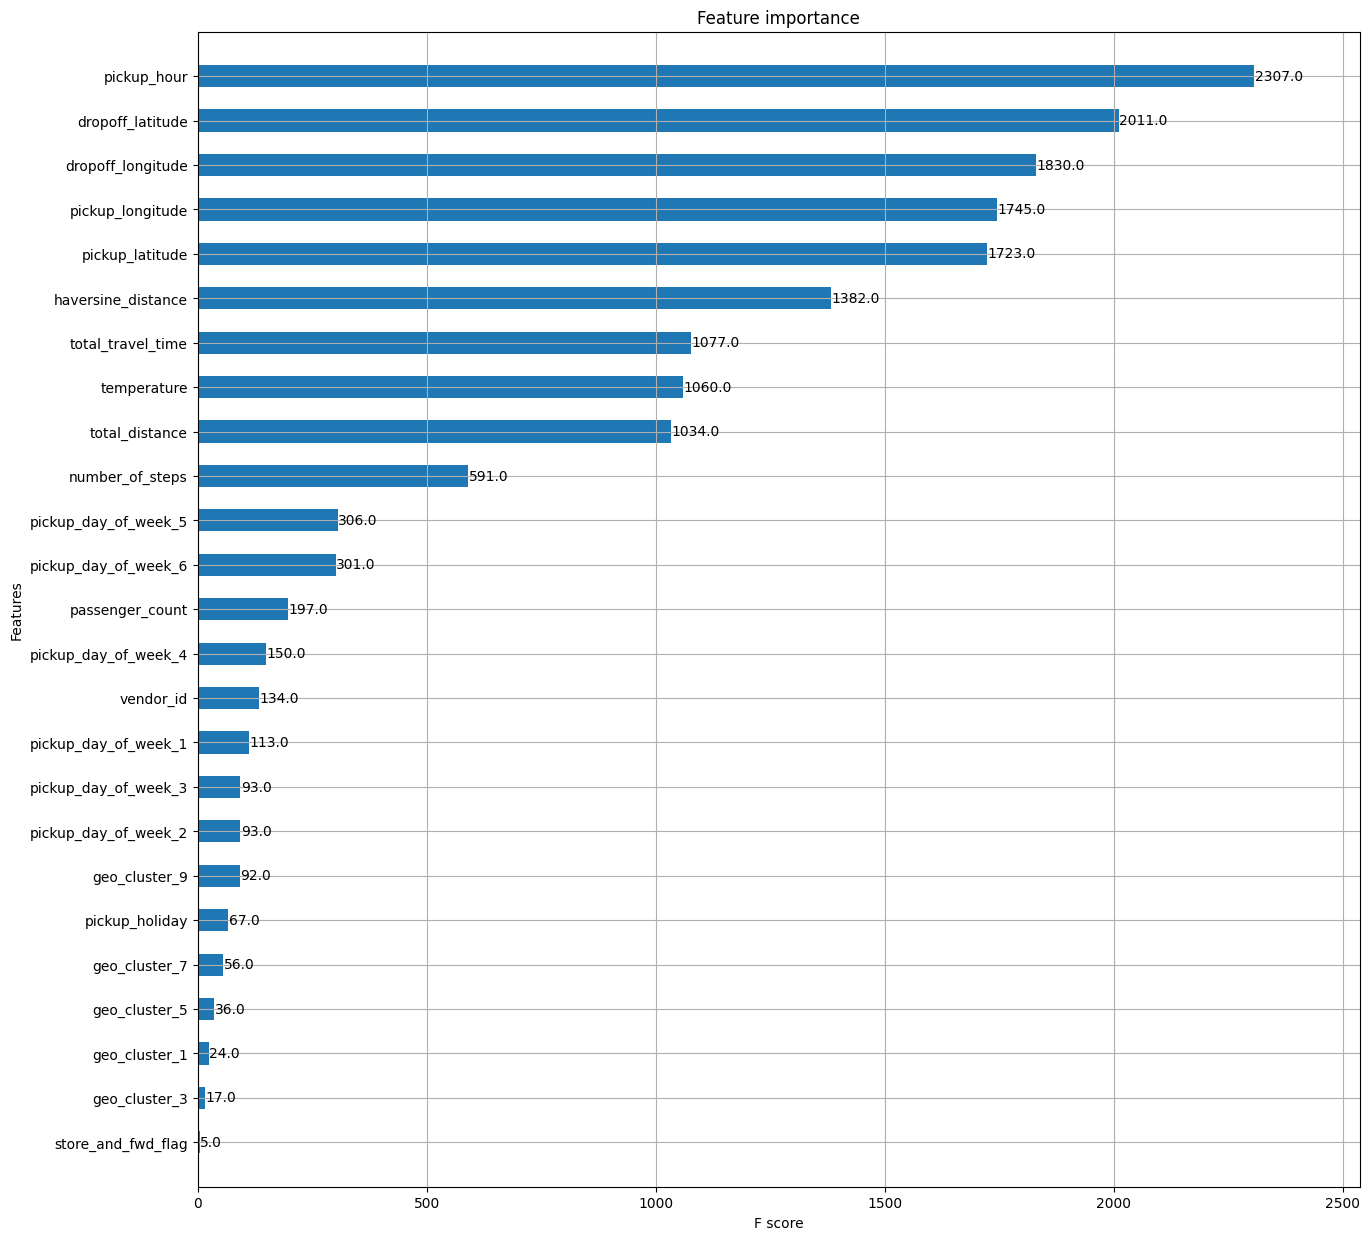

In [ ]:
fig, ax = plt.subplots(figsize = (15,15))
xgb.plot_importance(model, ax = ax, height=0.5)